# M1 — Exploratory Data Analysis

Goal: understand the LiDAR road-block dataset before any modelling (per `ROADMAP.md` M1).
We look at three things: the class distribution/imbalance, per-feature statistics per class,
and a bird's-eye-view (BEV) rendering of a few example tiles with intensity as colour.

All loading logic lives in `src/data.py` — this notebook only narrates and plots.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import CLASSES, FEATURE_NAMES, list_samples, load_points, get_splits

## 1. Class distribution & imbalance

The dataset is split across 6 folders (one per class). We count files per class — this is
cheap because `list_samples` only lists paths, it doesn't load any point-cloud arrays.

In [2]:
samples = list_samples()
counts = pd.Series([c for _, c, _ in samples]).value_counts().reindex(CLASSES)
counts

2lanes         473
3lanes         193
split4lanes    164
split6lanes    220
transition     242
crossing       133
Name: count, dtype: int64

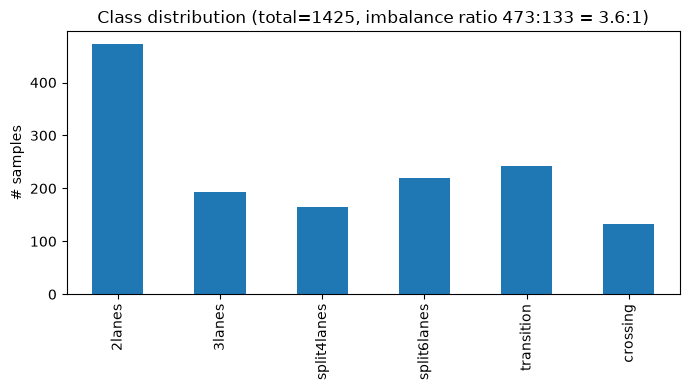

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax)
ax.set_ylabel("# samples")
ax.set_title(f"Class distribution (total={len(samples)}, imbalance ratio "
             f"{counts.max()}:{counts.min()} = {counts.max()/counts.min():.1f}:1)")
plt.tight_layout()
plt.show()

**Observation:** `2lanes` (largest) outnumbers `crossing` (smallest) by roughly 3.6:1. This
is why `src.data.get_splits` uses a **stratified** split — a plain random split could easily
over/under-represent a class in train/val/test — and why M2/M4 should evaluate per-class
metrics (not just overall accuracy) and consider class weighting or balanced subsampling.

## 2. Per-feature statistics per class

For each class we stack every point from every tile into one big `(N_points_total, 22)`
array and run `DataFrame.describe()`. This is per-**point** statistics (not per-cloud
aggregates yet — that engineering happens in M2), which tells us how each raw feature
behaves within a class before we decide how to aggregate it.

In [4]:
def class_points(class_name, samples):
    paths = [p for p, c, _ in samples if c == class_name]
    return np.concatenate([load_points(p) for p in paths], axis=0)

stats_per_class = {}
for class_name in CLASSES:
    pts = class_points(class_name, samples)
    df = pd.DataFrame(pts, columns=FEATURE_NAMES)
    stats_per_class[class_name] = df.describe().T[["mean", "std", "min", "max"]]

# Example: intensity (index 9) across classes — a feature the project brief flags as
# "most important factor apart from the geometry".
pd.concat(
    {c: stats_per_class[c].loc["intensity"] for c in CLASSES}, axis=1
).T

,mean,std,min,max
2lanes,35968.681727,6658.099036,19092.0,65535.0
3lanes,35672.286555,5996.311557,19289.0,65535.0
split4lanes,34705.592636,6408.853088,19638.0,65535.0
split6lanes,32604.719990,6045.242207,20053.0,65535.0
transition,35165.087185,6319.400275,19594.0,65535.0
crossing,34701.784491,6397.865560,19813.0,65535.0


In [5]:
# Full per-feature, per-class table (mean only) — a quick scan for features whose
# mean varies a lot across classes (candidates for M2 feature engineering).
means = pd.DataFrame({c: stats_per_class[c]["mean"] for c in CLASSES})
means

,2lanes,3lanes,split4lanes,split6lanes,transition,crossing
local_x,7.249840e+00,1.154864e+01,1.318338e+01,1.261587e+01,1.219763e+01,1.123010e+01
local_y,6.588339e+00,7.117888e+00,6.918537e+00,6.209151e+00,7.113641e+00,6.485243e+00
local_z,5.097189e-01,1.011060e+00,1.060214e+00,3.969634e-01,7.168094e-01,6.142460e-01
red,1.258878e+02,1.219227e+02,1.134664e+02,1.290835e+02,1.232916e+02,1.284257e+02
green,1.290225e+02,1.256277e+02,1.186644e+02,1.325249e+02,1.271503e+02,1.313753e+02
blue,1.180155e+02,1.163845e+02,1.103466e+02,1.223435e+02,1.189439e+02,1.226262e+02
global_x,4.436963e+02,4.354833e+02,3.395282e+02,4.495917e+02,3.483929e+02,3.235344e+02
global_y,4.586880e+02,6.628740e+02,5.633719e+02,5.005152e+02,5.147827e+02,4.758856e+02
global_z,6.423665e+01,5.757214e+01,5.664723e+01,5.687483e+01,5.686102e+01,5.747450e+01
intensity,3.596868e+04,3.567229e+04,3.470559e+04,3.260472e+04,3.516509e+04,3.470178e+04


## 3. BEV + intensity overlay

Road blocks are pre-aligned with driving direction along the y-axis and ground points
already isolated (per `CLAUDE.md`). Plotting local x vs local y with intensity as colour
gives an informal bird's-eye view — the same idea M3 formalises into an occupancy grid.

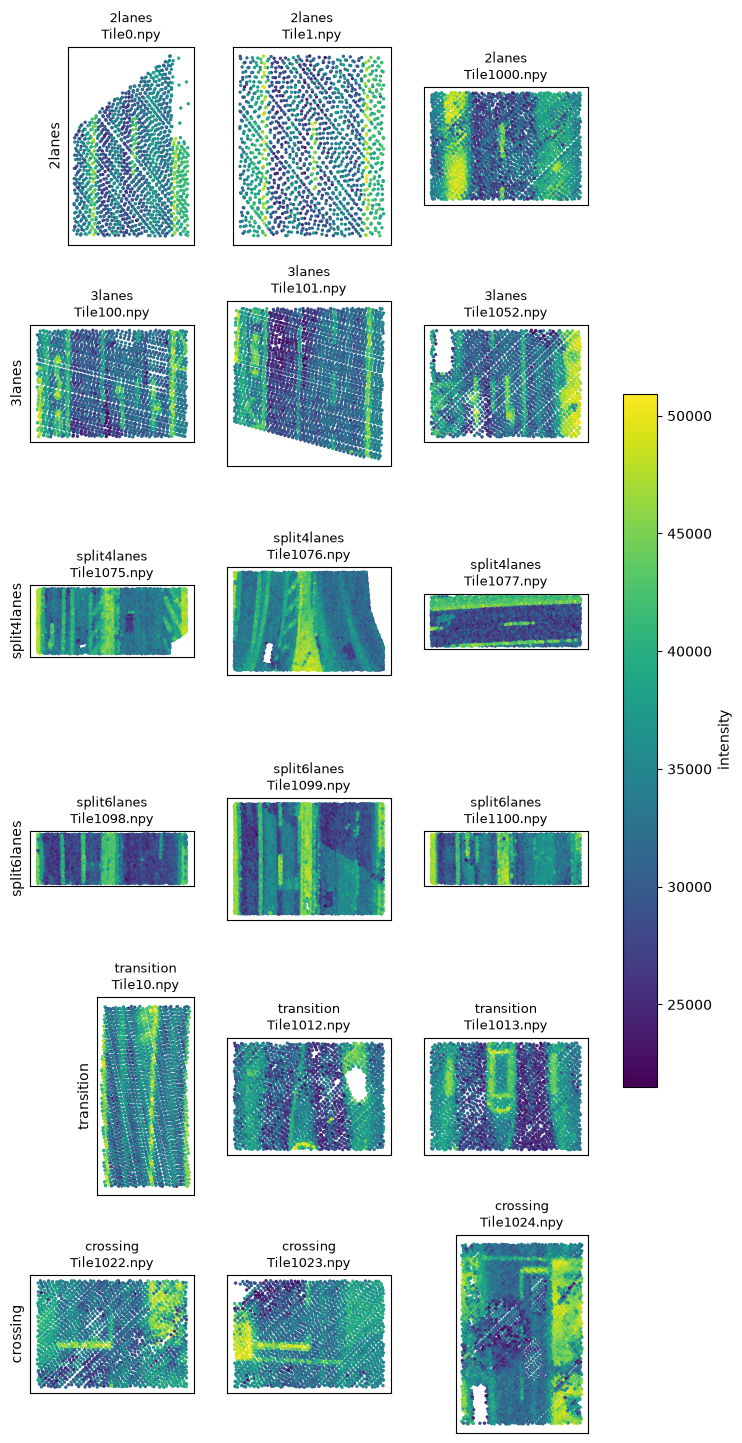

In [6]:
def plot_bev(points, ax, title=""):
    x, y, intensity = points[:, 0], points[:, 1], points[:, 9]
    sc = ax.scatter(x, y, c=intensity, s=2, cmap="viridis")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

n_examples = 3
fig, axes = plt.subplots(len(CLASSES), n_examples, figsize=(3 * n_examples, 3 * len(CLASSES)))
for row, class_name in enumerate(CLASSES):
    paths = [p for p, c, _ in samples if c == class_name][:n_examples]
    for col, path in enumerate(paths):
        pts = load_points(path)
        sc = plot_bev(pts, axes[row, col], title=f"{class_name}\n{path.split('/')[-1]}")
    axes[row, 0].set_ylabel(class_name, fontsize=10)
fig.colorbar(sc, ax=axes, label="intensity", shrink=0.5)
plt.show()

**Observation:** lane count is visible as the road's extent along local x, and
`transition`/`crossing` tiles show non-uniform width/branching along y — geometric signal
an aggregate 1D feature vector (M2) or a BEV occupancy grid (M3) should both be able to pick up.

## 4. Frozen train/val/test split

`get_splits()` builds an 80/15/5 stratified split the first time it's called and writes
`splits.json`; every later call (this notebook, M2, M3, ...) reads that same file, so the
test set is frozen from here on and never used for tuning.

In [7]:
splits = get_splits()
for name, split in splits.items():
    print(f"{name}: {len(split)} samples")

train: 1140 samples
val: 213 samples
test: 72 samples


## 5. Stratified vs. random split

`get_splits()` (§4) stratifies specifically because of the ~3.6:1 class imbalance from §1.
What would happen without it? `random_split()` builds the same 80/15/5 split with the same
mechanics, minus `stratify=` -- it is never frozen and never used for training or evaluation,
it exists only for this comparison.

In [8]:
from src.data import random_split

N_SEEDS = 500

def worst_class_count(split_samples):
    counts = pd.Series([c for _, c, _ in split_samples]).value_counts()
    return min(counts.get(c, 0) for c in CLASSES)

strat_test_worst = worst_class_count(splits["test"])
random_test_worst = np.array([worst_class_count(random_split(samples, seed=s)["test"]) for s in range(N_SEEDS)])

print(f"stratified split: worst-represented class in test has {strat_test_worst} tiles (crossing, "
      f"the smallest class overall)")
print(f"random split over {N_SEEDS} seeds: worst-represented class in test has "
      f"min={random_test_worst.min()} p5={np.percentile(random_test_worst, 5):.0f} "
      f"median={np.median(random_test_worst):.0f} max={random_test_worst.max()}")
print(f"fraction of random seeds at or below the stratified split's worst case: "
      f"{(random_test_worst <= strat_test_worst).mean():.1%}")

stratified split: worst-represented class in test has 7 tiles (crossing, the smallest class overall)
random split over 500 seeds: worst-represented class in test has min=1 p5=3 median=5 max=10
fraction of random seeds at or below the stratified split's worst case: 91.4%


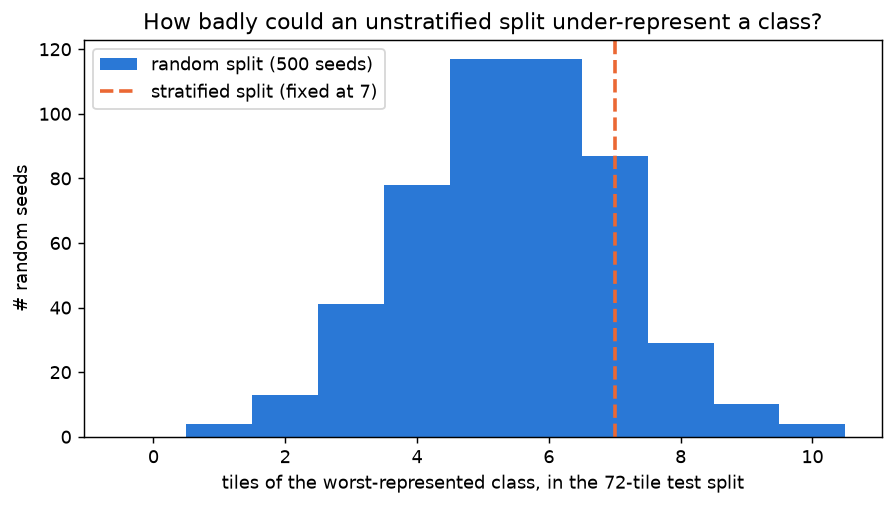

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(random_test_worst, bins=range(int(random_test_worst.max()) + 2), align="left",
        color="#2a78d6", label=f"random split ({N_SEEDS} seeds)")
ax.axvline(strat_test_worst, color="#eb6834", ls="--", lw=2,
           label=f"stratified split (fixed at {strat_test_worst})")
ax.set_xlabel("tiles of the worst-represented class, in the 72-tile test split")
ax.set_ylabel("# random seeds")
ax.set_title("How badly could an unstratified split under-represent a class?")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** a random split's worst-represented test class has a median of 5 tiles
against the stratified split's guaranteed 7, and 91% of random seeds do at least as badly.
The stratified split is not the median outcome of a random draw -- it is closer to the
lucky end, made deterministic instead of left to chance. With `crossing` at only 133 tiles
total (~7 fall in a 5% test split even proportionally), a single unlucky draw can leave a
class with just 1-2 test examples, exactly the scenario `get_splits()`'s `stratify=labels`
exists to rule out for `splits.json`, which -- once frozen -- gets exactly one real use, at
M5's final evaluation. The same pattern holds for the val split, just less sharply (val is
larger): stratified guarantees 20 `crossing` tiles, a random split's worst class has a
median of 19 and undercuts the stratified value 69% of the time.